# 03. Exploratory Data Analysis

## PART 1: Count Data

This notebook is used for the exploratory data anlysis of the processed count dataset before fitting the first-stage model for normal cycling counts.

We inspect variable types, categorical variable frequencies, continuous variable distributions, and the distribution of the modelling outcome.

The outcome for the first modelling stage is the 2-hour cyclist count. The variable `count_rescaled` is used as the modelling outcome because it represents the adjusted 2-hour count after handling mostly complete intervals with some missing 15-minute observations.

### Importing packages, establishing path and reading count data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
project_folder = Path("..")

processed_folder = project_folder / "data" / "processed"
diagnostics_folder = project_folder / "outputs" / "diagnostics"

diagnostics_folder.mkdir(parents=True, exist_ok=True)

In [3]:
counts_model_final = pd.read_csv(
    processed_folder / "counts_model_final.csv"
)

counts_model_final.head()

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,...,site_name,municipality,district,installation_date,direction_description,is_public_holiday,holiday_name,is_school_holiday,school_holiday_name,fuel_price_petrol_95
0,1,IN,2022,2022-05-01,5,Sunday,0,13.0,8,8,...,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
1,1,IN,2022,2022-05-01,5,Sunday,2,2.0,8,8,...,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
2,1,IN,2022,2022-05-01,5,Sunday,4,1.0,8,8,...,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
3,1,IN,2022,2022-05-01,5,Sunday,6,6.0,8,8,...,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
4,1,IN,2022,2022-05-01,5,Sunday,8,26.0,8,8,...,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153


### Structure of the dataset

In [4]:
print("Rows:", counts_model_final.shape[0])
print("Columns:", counts_model_final.shape[1])

Rows: 4587736
Columns: 27


In [5]:
counts_model_final.dtypes

site_id                         int64
direction                         str
year                            int64
date                              str
month                           int64
weekday                           str
hour_bin                        int64
count                         float64
observed_intervals              int64
total_intervals                 int64
missing_intervals               int64
missing_share                 float64
expected_intervals_for_row      int64
count_rescaled                  int64
rescaled                        int64
longitude                     float64
latitude                      float64
site_name                         str
municipality                      str
district                          str
installation_date                 str
direction_description             str
is_public_holiday               int64
holiday_name                      str
is_school_holiday               int64
school_holiday_name               str
fuel_price_p

In [6]:
pd.set_option("display.max_columns", None)
counts_model_final.head()

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,missing_intervals,missing_share,expected_intervals_for_row,count_rescaled,rescaled,longitude,latitude,site_name,municipality,district,installation_date,direction_description,is_public_holiday,holiday_name,is_school_holiday,school_holiday_name,fuel_price_petrol_95
0,1,IN,2022,2022-05-01,5,Sunday,0,13.0,8,8,0,0.0,8,13,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
1,1,IN,2022,2022-05-01,5,Sunday,2,2.0,8,8,0,0.0,8,2,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
2,1,IN,2022,2022-05-01,5,Sunday,4,1.0,8,8,0,0.0,8,1,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
3,1,IN,2022,2022-05-01,5,Sunday,6,6.0,8,8,0,0.0,8,6,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153
4,1,IN,2022,2022-05-01,5,Sunday,8,26.0,8,8,0,0.0,8,26,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.82153


In [7]:
pd.set_option("display.max_columns", None)
counts_model_final.tail()

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,missing_intervals,missing_share,expected_intervals_for_row,count_rescaled,rescaled,longitude,latitude,site_name,municipality,district,installation_date,direction_description,is_public_holiday,holiday_name,is_school_holiday,school_holiday_name,fuel_price_petrol_95
4587731,152,OUT,2026,2026-04-30,4,Thursday,14,102.0,8,8,0,0.0,8,102,0,4.149169,50.968901,Opwijk,District Vilvoorde-gewestwegen,Opwijk,2025-10-31,Opwijk Fietser rich Aalst,0,No public holiday,0,No school holiday,1.82212
4587732,152,OUT,2026,2026-04-30,4,Thursday,16,82.0,8,8,0,0.0,8,82,0,4.149169,50.968901,Opwijk,District Vilvoorde-gewestwegen,Opwijk,2025-10-31,Opwijk Fietser rich Aalst,0,No public holiday,0,No school holiday,1.82212
4587733,152,OUT,2026,2026-04-30,4,Thursday,18,27.0,8,8,0,0.0,8,27,0,4.149169,50.968901,Opwijk,District Vilvoorde-gewestwegen,Opwijk,2025-10-31,Opwijk Fietser rich Aalst,0,No public holiday,0,No school holiday,1.82212
4587734,152,OUT,2026,2026-04-30,4,Thursday,20,17.0,8,8,0,0.0,8,17,0,4.149169,50.968901,Opwijk,District Vilvoorde-gewestwegen,Opwijk,2025-10-31,Opwijk Fietser rich Aalst,0,No public holiday,0,No school holiday,1.82212
4587735,152,OUT,2026,2026-04-30,4,Thursday,22,4.0,8,8,0,0.0,8,4,0,4.149169,50.968901,Opwijk,District Vilvoorde-gewestwegen,Opwijk,2025-10-31,Opwijk Fietser rich Aalst,0,No public holiday,0,No school holiday,1.82212


Converting date variable into date format variable

In [8]:
date_columns = [
    "date",
    "installation_date",
]

for column in date_columns:
    if column in counts_model_final.columns:
        counts_model_final[column] = pd.to_datetime(
            counts_model_final[column],
            errors="coerce"
        )

### Defining variable groups

In [9]:
outcome_variable = "count_rescaled"

categorical_variables = [
    "site_id",
    "direction",
    "year",
    "month",
    "weekday",
    "hour_bin",
    "municipality",
    "district",
    "is_public_holiday",
    "holiday_name",
    "is_school_holiday",
    "school_holiday_name",
]

continuous_variables = [
    "fuel_price_petrol_95",
]

In [10]:
categorical_variables = [
    variable for variable in categorical_variables
    if variable in counts_model_final.columns
]

continuous_variables = [
    variable for variable in continuous_variables
    if variable in counts_model_final.columns
]

In [11]:
print("Categorical variables:")
print(categorical_variables)

print("\nContinuous variables:")
print(continuous_variables)

Categorical variables:
['site_id', 'direction', 'year', 'month', 'weekday', 'hour_bin', 'municipality', 'district', 'is_public_holiday', 'holiday_name', 'is_school_holiday', 'school_holiday_name']

Continuous variables:
['fuel_price_petrol_95']


### Outcome varaible distribution

In [12]:
counts_model_final[outcome_variable].describe()

count    4.587736e+06
mean     2.135951e+01
std      4.899166e+01
min      0.000000e+00
25%      0.000000e+00
50%      4.000000e+00
75%      2.100000e+01
max      8.682000e+03
Name: count_rescaled, dtype: float64

In [13]:
print("Minimum count:", counts_model_final[outcome_variable].min())
print("Maximum count:", counts_model_final[outcome_variable].max())
print("Mean count:", counts_model_final[outcome_variable].mean())
print("Median count:", counts_model_final[outcome_variable].median())
print("Share of zero counts:", (counts_model_final[outcome_variable] == 0).mean())

Minimum count: 0
Maximum count: 8682
Mean count: 21.359510442623552
Median count: 4.0
Share of zero counts: 0.2734843504508542


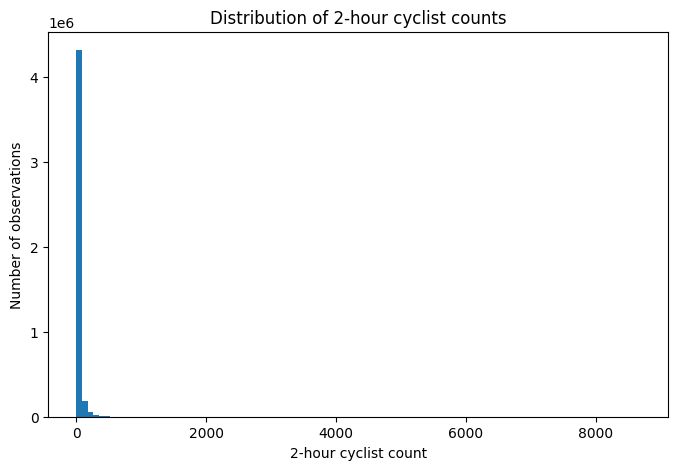

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(counts_model_final[outcome_variable], bins=100)
plt.title("Distribution of 2-hour cyclist counts")
plt.xlabel("2-hour cyclist count")
plt.ylabel("Number of observations")
plt.show()

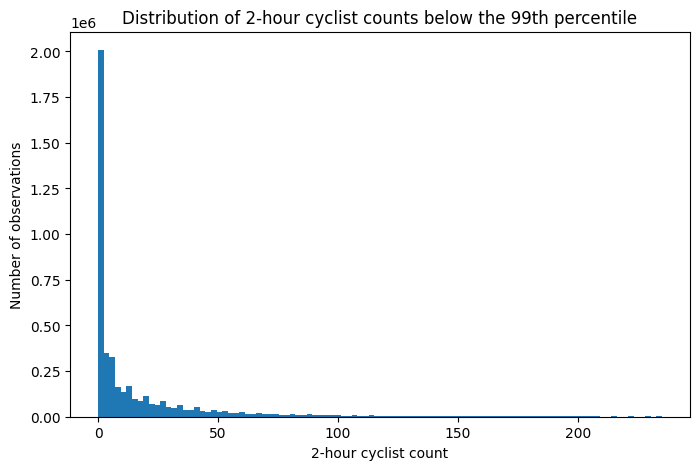

In [15]:
upper_limit = counts_model_final[outcome_variable].quantile(0.99)

plt.figure(figsize=(8, 5))
plt.hist(
    counts_model_final.loc[
        counts_model_final[outcome_variable] <= upper_limit,
        outcome_variable
    ],
    bins=100
)
plt.title("Distribution of 2-hour cyclist counts below the 99th percentile")
plt.xlabel("2-hour cyclist count")
plt.ylabel("Number of observations")
plt.show()

In [16]:
zero_summary = (
    counts_model_final
    .assign(is_zero_count=(counts_model_final[outcome_variable] == 0).astype(int))
    .groupby(["year", "month"])
    .agg(
        observations=(outcome_variable, "size"),
        zero_counts=("is_zero_count", "sum"),
        zero_share=("is_zero_count", "mean"),
    )
    .reset_index()
)

zero_summary

,year,month,observations,zero_counts,zero_share
0,2022,5,34796,8563,0.246092
1,2022,6,45336,11503,0.253728
2,2022,7,64382,15657,0.243189
3,2022,8,79314,19365,0.244156
4,2022,9,81064,22279,0.274832
5,2022,10,92264,24689,0.267591
6,2022,11,92544,27494,0.297091
7,2022,12,95202,32288,0.339153
8,2023,1,95414,31585,0.331031
9,2023,2,88074,26006,0.295274


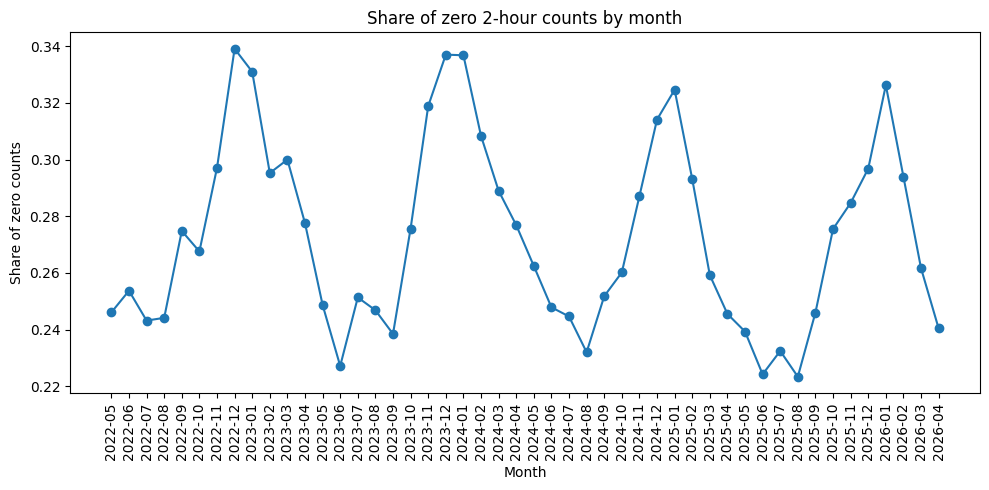

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(
    zero_summary["year"].astype(str) + "-" + zero_summary["month"].astype(str).str.zfill(2),
    zero_summary["zero_share"],
    marker="o"
)
plt.xticks(rotation=90)
plt.title("Share of zero 2-hour counts by month")
plt.xlabel("Month")
plt.ylabel("Share of zero counts")
plt.tight_layout()
plt.show()

**Overdispersion**

In [18]:
outcome_mean = counts_model_final[outcome_variable].mean()
outcome_variance = counts_model_final[outcome_variable].var()

print("Mean:", outcome_mean)
print("Variance:", outcome_variance)
print("Variance-to-mean ratio:", outcome_variance / outcome_mean)

Mean: 21.359510442623552
Variance: 2400.1831423144695
Variance-to-mean ratio: 112.37070010391395


In [19]:
dispersion_by_site = (
    counts_model_final
    .groupby("site_id")
    .agg(
        mean_count=(outcome_variable, "mean"),
        variance_count=(outcome_variable, "var"),
        observations=(outcome_variable, "size"),
    )
    .reset_index()
)

dispersion_by_site["variance_to_mean_ratio"] = (
    dispersion_by_site["variance_count"] / dispersion_by_site["mean_count"]
)

dispersion_by_site = dispersion_by_site.sort_values(
    "variance_to_mean_ratio",
    ascending=False
)

pd.set_option("display.max_rows", None)
dispersion_by_site

,site_id,mean_count,variance_count,observations,variance_to_mean_ratio
139,142,190.502033,45653.920647,984,239.650570
63,64,90.386941,21648.763665,33832,239.512073
121,122,30.921305,7166.346077,31298,231.760791
138,140,82.188405,14118.410204,26236,171.781046
135,137,83.315190,13331.610296,26162,160.014162
140,143,182.752530,28653.644463,21150,156.789318
136,138,79.513472,12370.479685,26574,155.577154
106,107,185.158676,27107.596276,32330,146.401977
124,125,66.898187,9708.180155,30890,145.118733
65,66,43.862980,5794.399132,33652,132.102268


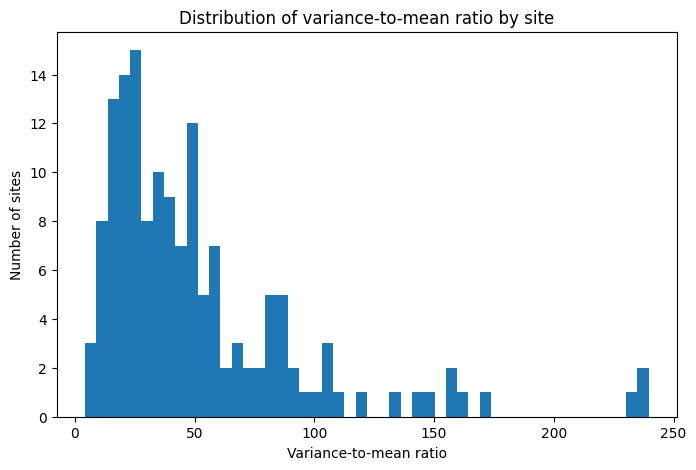

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(
    dispersion_by_site["variance_to_mean_ratio"].replace([float("inf")], pd.NA).dropna(),
    bins=50
)
plt.title("Distribution of variance-to-mean ratio by site")
plt.xlabel("Variance-to-mean ratio")
plt.ylabel("Number of sites")
plt.show()

### Categorical predictors

In [21]:
def categorical_count_table(data, variable):
    table = (
        data[variable]
        .value_counts(dropna=False)
        .reset_index()
    )

    table.columns = [variable, "count"]
    table["percentage"] = 100 * table["count"] / len(data)

    return table

In [22]:
for variable in categorical_variables:
    print("\n" + "=" * 80)
    print(variable)
    display(categorical_count_table(counts_model_final, variable).head(30))


site_id


,site_id,count,percentage
0,2,35056,0.764124
1,4,35056,0.764124
2,5,35056,0.764124
3,8,35056,0.764124
4,9,35056,0.764124
5,10,35056,0.764124
6,11,35056,0.764124
7,13,35056,0.764124
8,14,35056,0.764124
9,15,35056,0.764124



direction


,direction,count,percentage
0,IN,2293874,50.000131
1,OUT,2293862,49.999869



year


...

,holiday_name,count,percentage
0,No public holiday,4414804,96.230559
1,Good Friday,13200,0.287724
2,Easter Monday,13152,0.286677
3,All Saints' Day,13080,0.285108
4,Armistice Day,13080,0.285108
5,Christmas Day,12960,0.282492
6,St. Stephen's Day,12960,0.282492
7,New Year's Day,12954,0.282361
8,Easter Sunday,12902,0.281228
9,Assumption Day,12364,0.269501



is_school_holiday


,is_school_holiday,count,percentage
0,0,3281386,71.525171
1,1,1306350,28.474829



school_holiday_name


,school_holiday_name,count,percentage
0,No school holiday,3281386,71.525171
1,Summer Holidays,753754,16.429760
2,Spring Holidays,187858,4.094787
3,Winter Holidays,181352,3.952974
4,Carnival Holidays,91934,2.003908
5,All Saints Holidays,91452,1.993402


### Continuous predictors

In [23]:
counts_model_final[continuous_variables].describe().T

,count,mean,std,min,25%,50%,75%,max
fuel_price_petrol_95,4587736.0,1.65791,0.116624,1.4482,1.55825,1.64865,1.71891,2.11083


In [24]:
def plot_histogram(data, variable, bins=50):
    plt.figure(figsize=(8, 5))
    plt.hist(data[variable].dropna(), bins=bins)
    plt.title(f"Distribution of {variable}")
    plt.xlabel(variable)
    plt.ylabel("Number of observations")
    plt.tight_layout()
    plt.show()

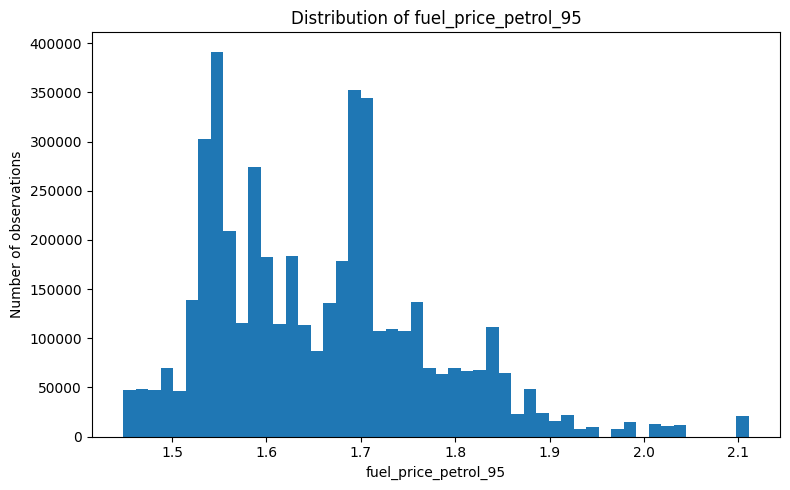

In [25]:
for variable in continuous_variables:
    plot_histogram(counts_model_final, variable)

## PART 2: Deviations Data

### Load data

In [26]:
prediction_data = pd.read_csv(
    processed_folder / "prediction_data_with_factors.csv"
)

prediction_data.head()

C:\Users\neris\AppData\Local\Temp\ipykernel_38428\2833737698.py:1: DtypeWarning: Columns (0: outdoor_music_event_type, 1: indoor_music_event_type, 2: sport_event_type) have mixed types. Specify dtype option on import or set low_memory=False.
  prediction_data = pd.read_csv(


,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,missing_intervals,missing_share,expected_intervals_for_row,count_rescaled,rescaled,longitude,latitude,site_name,municipality,district,installation_date,direction_description,is_public_holiday,holiday_name,is_school_holiday,school_holiday_name,fuel_price_petrol_95,coord_combo,geopy_municipality,geopy_province,geopy_region,temperature_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_mean,precipitation_category,is_strike,is_outdoor_music,outdoor_music_event_type,is_indoor_music,indoor_music_event_type,is_sport_event,sport_event_type
0,1,IN,2025,2025-05-01,5,Thursday,0,1.0,8,8,0,0.0,8,1.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,15.00,0.0,0.0,0.0,5.95,dry,0,0,NaN,0,NaN,0,NaN
1,1,IN,2025,2025-05-01,5,Thursday,2,1.0,8,8,0,0.0,8,1.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,13.05,0.0,0.0,0.0,5.80,dry,0,0,NaN,0,NaN,0,NaN
2,1,IN,2025,2025-05-01,5,Thursday,4,3.0,8,8,0,0.0,8,3.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,11.20,0.0,0.0,0.0,5.10,dry,0,0,NaN,0,NaN,0,NaN
3,1,IN,2025,2025-05-01,5,Thursday,6,3.0,8,8,0,0.0,8,3.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,10.50,0.0,0.0,0.0,5.95,dry,0,0,NaN,0,NaN,0,NaN
4,1,IN,2025,2025-05-01,5,Thursday,8,43.0,8,8,0,0.0,8,43.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,14.55,0.0,0.0,0.0,6.00,dry,0,0,NaN,0,NaN,0,NaN


### Validation and structural check

In [27]:
print(f"Total Rows: {prediction_data.shape[0]}")
print(f"Total Columns: {prediction_data.shape[1]}")

Total Rows: 1177575
Total Columns: 44


In [28]:
prediction_data.dtypes

site_id                         int64
direction                         str
year                            int64
date                              str
month                           int64
weekday                           str
hour_bin                        int64
count                         float64
observed_intervals              int64
total_intervals                 int64
missing_intervals               int64
missing_share                 float64
expected_intervals_for_row      int64
count_rescaled                float64
rescaled                        int64
longitude                     float64
latitude                      float64
site_name                         str
municipality                      str
district                          str
installation_date                 str
direction_description             str
is_public_holiday               int64
holiday_name                      str
is_school_holiday               int64
school_holiday_name               str
fuel_price_p

In [29]:
pd.set_option("display.max_columns", None)
prediction_data.head()

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,missing_intervals,missing_share,expected_intervals_for_row,count_rescaled,rescaled,longitude,latitude,site_name,municipality,district,installation_date,direction_description,is_public_holiday,holiday_name,is_school_holiday,school_holiday_name,fuel_price_petrol_95,coord_combo,geopy_municipality,geopy_province,geopy_region,temperature_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_mean,precipitation_category,is_strike,is_outdoor_music,outdoor_music_event_type,is_indoor_music,indoor_music_event_type,is_sport_event,sport_event_type
0,1,IN,2025,2025-05-01,5,Thursday,0,1.0,8,8,0,0.0,8,1.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,15.00,0.0,0.0,0.0,5.95,dry,0,0,NaN,0,NaN,0,NaN
1,1,IN,2025,2025-05-01,5,Thursday,2,1.0,8,8,0,0.0,8,1.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,13.05,0.0,0.0,0.0,5.80,dry,0,0,NaN,0,NaN,0,NaN
2,1,IN,2025,2025-05-01,5,Thursday,4,3.0,8,8,0,0.0,8,3.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,11.20,0.0,0.0,0.0,5.10,dry,0,0,NaN,0,NaN,0,NaN
3,1,IN,2025,2025-05-01,5,Thursday,6,3.0,8,8,0,0.0,8,3.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,10.50,0.0,0.0,0.0,5.95,dry,0,0,NaN,0,NaN,0,NaN
4,1,IN,2025,2025-05-01,5,Thursday,8,43.0,8,8,0,0.0,8,43.0,0,4.456122,50.916183,Machelen,Machelen,AWV212,2019-08-22,Machelen Cyclists rich. Brucargo,1,Labour Day,0,No school holiday,1.51433,"50.91618331151478, 4.456121776137429",Machelen,Flemish Brabant,Flanders,14.55,0.0,0.0,0.0,6.00,dry,0,0,NaN,0,NaN,0,NaN


In [30]:
pd.set_option("display.max_columns", None)
prediction_data.tail()

,site_id,direction,year,date,month,weekday,hour_bin,count,observed_intervals,total_intervals,missing_intervals,missing_share,expected_intervals_for_row,count_rescaled,rescaled,longitude,latitude,site_name,municipality,district,installation_date,direction_description,is_public_holiday,holiday_name,is_school_holiday,school_holiday_name,fuel_price_petrol_95,coord_combo,geopy_municipality,geopy_province,geopy_region,temperature_mean,precipitation_sum,rain_sum,snowfall_sum,wind_speed_mean,precipitation_category,is_strike,is_outdoor_music,outdoor_music_event_type,is_indoor_music,indoor_music_event_type,is_sport_event,sport_event_type
1177570,143,OUT,2026,2026-04-30,4,Thursday,14,385.0,8,8,0,0.0,8,385.0,0,3.26286,50.83066,Eco Display Classic Budastraat,Kortrijk,NaN,2023-12-08,YTH17062596 Cyclists OUT,0,No public holiday,0,No school holiday,1.82212,"50.83066, 3.26286",Kortrijk,West Flanders,Flanders,19.80,0.0,0.0,0.0,19.00,dry,0,0,NaN,0,NaN,0,NaN
1177571,143,OUT,2026,2026-04-30,4,Thursday,16,860.0,8,8,0,0.0,8,860.0,0,3.26286,50.83066,Eco Display Classic Budastraat,Kortrijk,NaN,2023-12-08,YTH17062596 Cyclists OUT,0,No public holiday,0,No school holiday,1.82212,"50.83066, 3.26286",Kortrijk,West Flanders,Flanders,20.45,0.0,0.0,0.0,19.25,dry,0,0,NaN,0,NaN,0,NaN
1177572,143,OUT,2026,2026-04-30,4,Thursday,18,394.0,8,8,0,0.0,8,394.0,0,3.26286,50.83066,Eco Display Classic Budastraat,Kortrijk,NaN,2023-12-08,YTH17062596 Cyclists OUT,0,No public holiday,0,No school holiday,1.82212,"50.83066, 3.26286",Kortrijk,West Flanders,Flanders,20.35,0.0,0.0,0.0,19.20,dry,0,0,NaN,0,NaN,0,NaN
1177573,143,OUT,2026,2026-04-30,4,Thursday,20,193.0,8,8,0,0.0,8,193.0,0,3.26286,50.83066,Eco Display Classic Budastraat,Kortrijk,NaN,2023-12-08,YTH17062596 Cyclists OUT,0,No public holiday,0,No school holiday,1.82212,"50.83066, 3.26286",Kortrijk,West Flanders,Flanders,18.70,0.0,0.0,0.0,15.15,dry,0,0,NaN,0,NaN,0,NaN
1177574,143,OUT,2026,2026-04-30,4,Thursday,22,144.0,8,8,0,0.0,8,144.0,0,3.26286,50.83066,Eco Display Classic Budastraat,Kortrijk,NaN,2023-12-08,YTH17062596 Cyclists OUT,0,No public holiday,0,No school holiday,1.82212,"50.83066, 3.26286",Kortrijk,West Flanders,Flanders,16.10,0.0,0.0,0.0,15.40,dry,0,0,NaN,0,NaN,0,NaN


In [33]:
date_columns = [
    "date",
    "installation_date"
]

for column in date_columns:
    if column in prediction_data.columns:
        prediction_data[column] = pd.to_datetime(
           prediction_data[column],
            errors="coerce"
        )

### Missing data check (Mostly for rechecking new-created columns)

In [34]:
prediction_data.isna().sum()

site_id                             0
direction                           0
year                                0
date                                0
month                               0
weekday                             0
hour_bin                            0
count                               0
observed_intervals                  0
total_intervals                     0
missing_intervals                   0
missing_share                       0
expected_intervals_for_row          0
count_rescaled                      0
rescaled                            0
longitude                           0
latitude                            0
site_name                           0
municipality                        0
district                         6562
installation_date                   0
direction_description               0
is_public_holiday                   0
holiday_name                        0
is_school_holiday                   0
school_holiday_name                 0
fuel_price_p

Found missing event types. I thought we coded them as "No event" already? Maybe I got the old set, I'll update here, and we can combine all together later.

In [35]:
event_type_columns = [
    'outdoor_music_event_type', 
    'indoor_music_event_type', 
    'sport_event_type'
]

for col in event_type_columns:
    if col in prediction_data.columns:
        prediction_data[col] = prediction_data[col].fillna("No event")

In [36]:
prediction_data.isna().sum()

site_id                          0
direction                        0
year                             0
date                             0
month                            0
weekday                          0
hour_bin                         0
count                            0
observed_intervals               0
total_intervals                  0
missing_intervals                0
missing_share                    0
expected_intervals_for_row       0
count_rescaled                   0
rescaled                         0
longitude                        0
latitude                         0
site_name                        0
municipality                     0
district                      6562
installation_date                0
direction_description            0
is_public_holiday                0
holiday_name                     0
is_school_holiday                0
school_holiday_name              0
fuel_price_petrol_95             0
coord_combo                      0
geopy_municipality  

### Defining variable groups

In [37]:
categorical_variables = [
    "weekday", "hour_bin", "month", 
    "geopy_region", "geopy_province", "geopy_municipality",
    "is_public_holiday", "holiday_name", "is_school_holiday", "school_holiday_name",
    "precipitation_category", # <-- NEW Weather category
    "is_strike", "is_outdoor_music", "outdoor_music_event_type",
    "is_indoor_music", "indoor_music_event_type", "is_sport_event", "sport_event_type"
]

continuous_variables = [
    "fuel_price_petrol_95",
    "temperature_mean",     
    "precipitation_sum", 
    "rain_sum", 
    "snowfall_sum", 
    "wind_speed_mean"
]

categorical_variables = [var for var in categorical_variables if var in prediction_data.columns]
continuous_variables = [var for var in continuous_variables if var in prediction_data.columns]

print(f"Tracking {len(categorical_variables)} Categorical Variables.")
print(f"Tracking {len(continuous_variables)} Continuous Variables.")

Tracking 18 Categorical Variables.
Tracking 6 Continuous Variables.


### Categorical predictors

In [38]:
def categorical_count_table(data, variable):
    table = (
        data[variable]
        .value_counts(dropna=False)
        .reset_index()
    )

    table.columns = [variable, "count"]
    table["percentage"] = 100 * table["count"] / len(data)

    return table

In [40]:
for variable in categorical_variables:
    print("\n" + "=" * 80)
    print(variable)
    display(categorical_count_table(prediction_data, variable).head(30))


weekday


,weekday,count,percentage
0,Thursday,171006,14.521878
1,Monday,167848,14.253699
2,Saturday,167821,14.251406
3,Friday,167805,14.250048
4,Tuesday,167763,14.246481
5,Wednesday,167741,14.244613
6,Sunday,167591,14.231875



hour_bin


,hour_bin,count,percentage
0,14,98164,8.336114
1,12,98163,8.336030
2,18,98162,8.335945
3,20,98162,8.335945
4,10,98160,8.335775
5,22,98160,8.335775
6,16,98159,8.335690
7,6,98156,8.335435
8,8,98153,8.335180
9,0,98150,8.334926



month


...

,indoor_music_event_type,count,percentage
0,No event,1177287,99.975543
1,indoor concert,150,0.012738
2,indoor music festival,54,0.004586
3,indoor electronic concert,48,0.004076
4,indoor orchestral concert,24,0.002038
5,musical concert/show,12,0.001019



is_sport_event


,is_sport_event,count,percentage
0,0,1175971,99.863788
1,1,1604,0.136212



sport_event_type


,sport_event_type,count,percentage
0,No event,1175971,99.863788
1,cycling participation event,648,0.055028
2,cyclocross race,432,0.036686
3,road cycling race,264,0.022419
4,cyclocross world cup,120,0.010190
5,road cycling stage race,96,0.008152
6,running event,44,0.003736


### Continuous predictors

In [44]:
prediction_data[continuous_variables].describe().T

,count,mean,std,min,25%,50%,75%,max
fuel_price_petrol_95,1177575.0,1.569154,0.105046,1.4482,1.52342,1.54093,1.55825,1.8965
temperature_mean,1177575.0,12.085717,6.705686,-7.2000,7.30000,12.00000,16.65000,37.2000
precipitation_sum,1177575.0,0.149679,0.565626,0.0000,0.00000,0.00000,0.00000,19.6000
rain_sum,1177575.0,0.141433,0.546132,0.0000,0.00000,0.00000,0.00000,19.6000
snowfall_sum,1177575.0,0.005776,0.090623,0.0000,0.00000,0.00000,0.00000,10.7100
wind_speed_mean,1177575.0,12.601872,6.067722,0.1000,8.00000,11.85000,16.45000,51.4000


In [42]:
def plot_histogram(data, variable, bins=50):
    plt.figure(figsize=(8, 5))
    plt.hist(data[variable].dropna(), bins=bins)
    plt.title(f"Distribution of {variable}")
    plt.xlabel(variable)
    plt.ylabel("Number of observations")
    plt.tight_layout()
    plt.show()

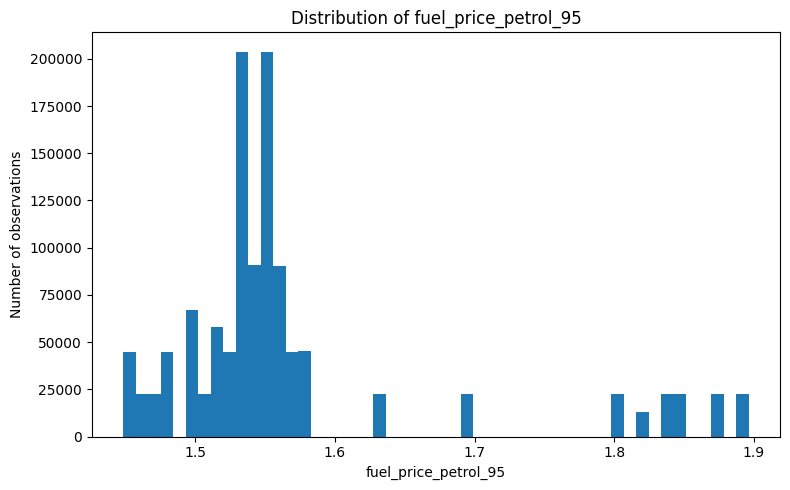

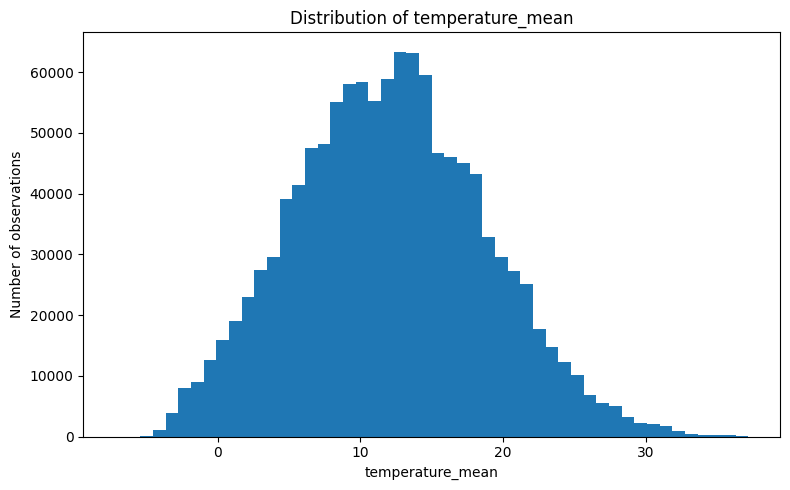

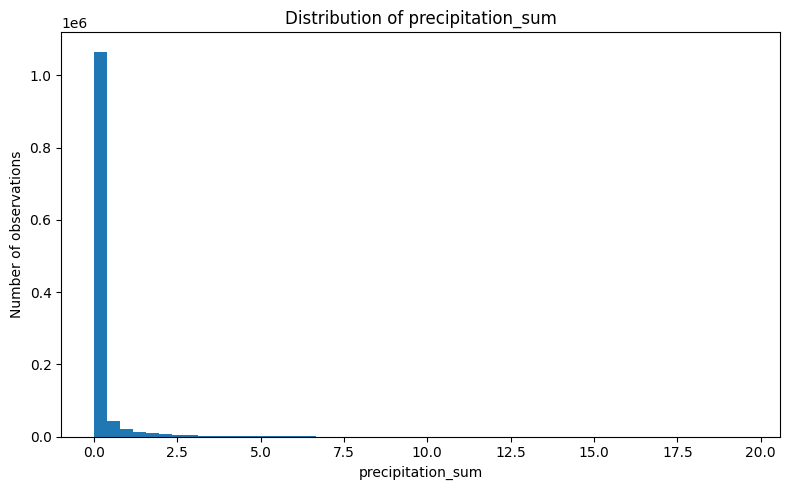

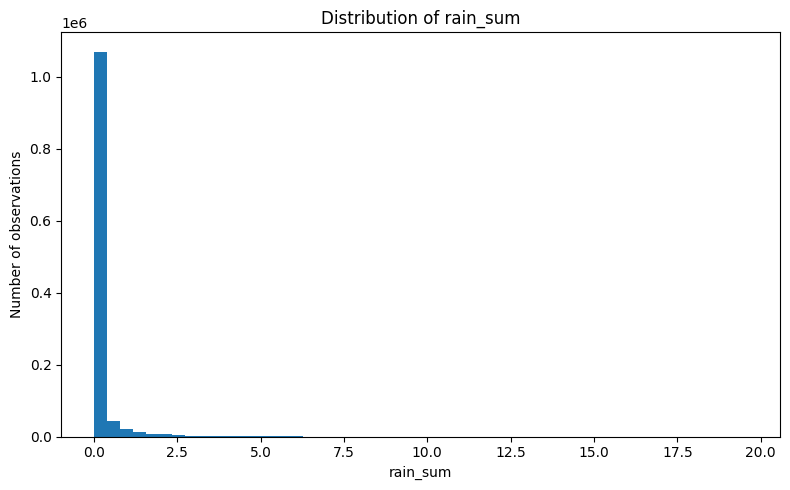

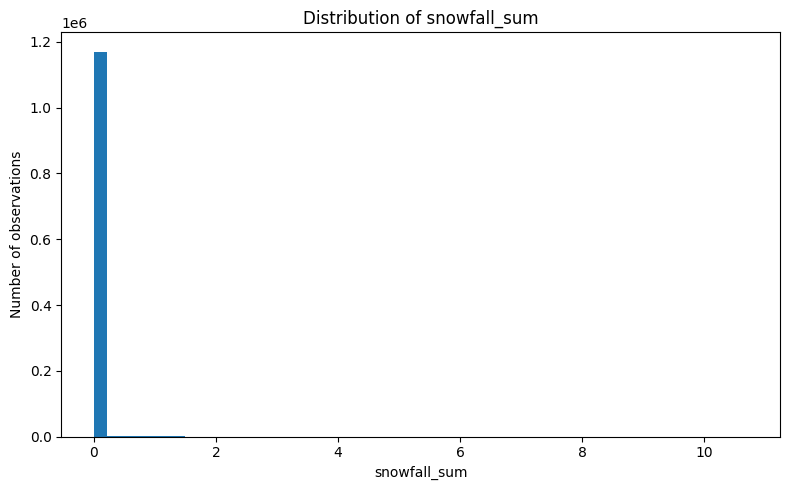

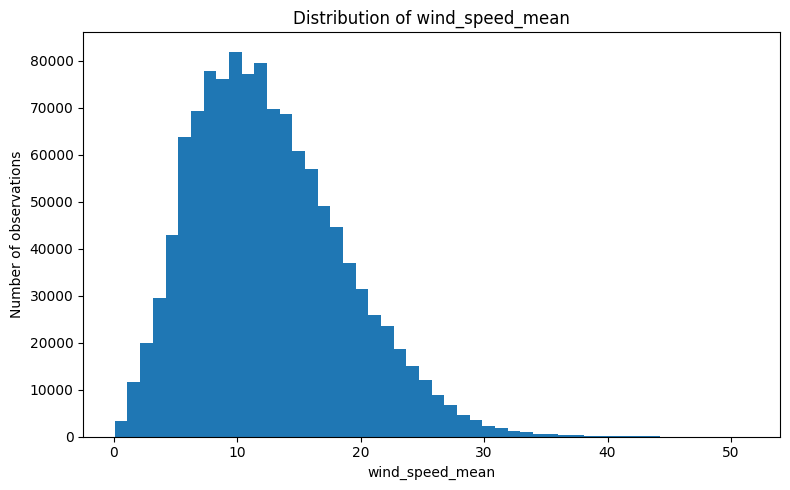

In [43]:
for variable in continuous_variables:
    plot_histogram(prediction_data, variable)